# Principal Component Analysis (PCA)

- PCA: reduces high-dimensional data to fewer dimensions by finding directions of maximum variance
- Unsupervised — does not use class labels, only the feature variance structure
- Dataset: breast_cancer.csv (compressing 30 features to 2 principal components)
[https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('/content/breast-cancer.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df = df.drop(columns=[col for col in ["id", "Unnamed: 32"] if col in df.columns])

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # M=1, B=0

X = df.drop("diagnosis", axis=1)
Y = df["diagnosis"]

print("Shape:", X.shape)
print(X.head())

Shape: (569, 30)
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_wors

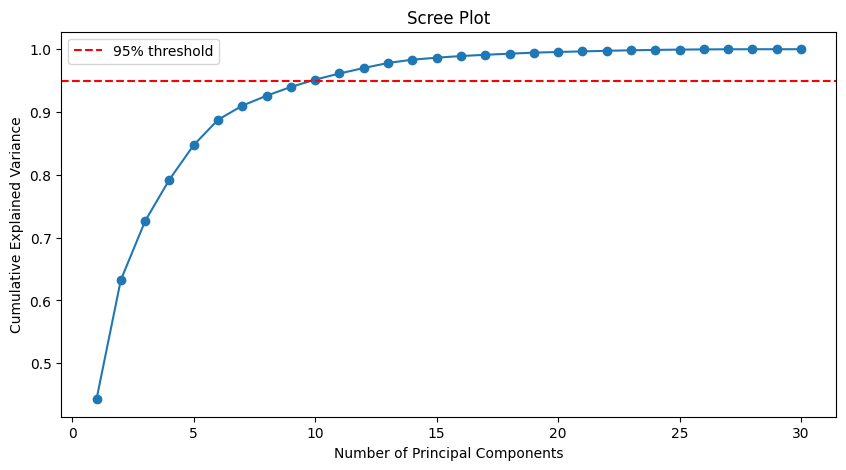

Variance explained by PC1: 0.4427
Variance explained by PC2: 0.1897
Total (PC1+PC2)           : 0.6324


In [6]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

pca_full = PCA(n_components=30)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), cumulative, marker="o")
plt.axhline(y=0.95, color="r", linestyle="--", label="95% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.legend()
plt.show()

print("Variance explained by PC1:", round(explained[0], 4))
print("Variance explained by PC2:", round(explained[1], 4))
print("Total (PC1+PC2)           :", round(explained[0]+explained[1], 4))

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape :", X_pca.shape)

Original shape: (569, 30)
Reduced shape : (569, 2)


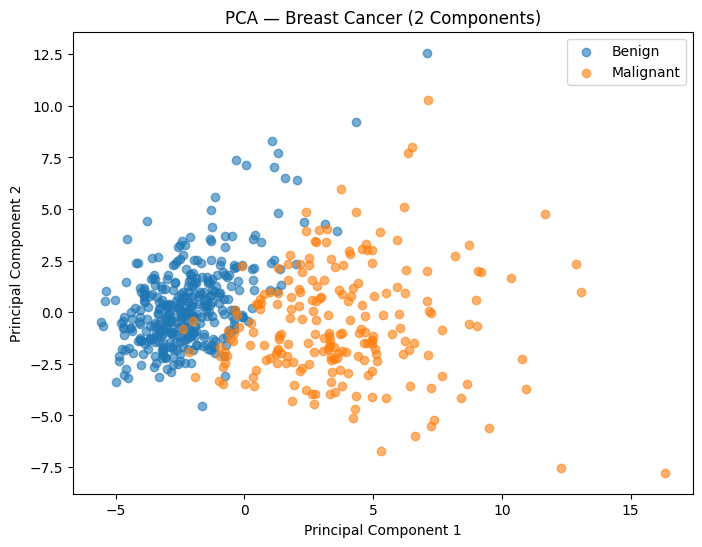

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[Y==0, 0], X_pca[Y==0, 1], label="Benign",    alpha=0.6)
plt.scatter(X_pca[Y==1, 0], X_pca[Y==1, 1], label="Malignant", alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA — Breast Cancer (2 Components)")
plt.legend()
plt.show()

## Conclusion
- PCA compressed 30 features into 2 principal components with minimal information loss
- The scree plot showed how many components are needed to retain 95% of variance
- The 2D scatter plot shows malignant and benign tumors naturally separating in PC space — even though PCA never used the diagnosis labels
- This confirms the 30 features carry strong class-relevant structure, and PCA successfully captured it in just 2 directions